# Task A: Dataset Audit and Variable Classification

## **Task A1:** Structural Inspection

In [1]:
import pandas as pd
import numpy as np

# Load csv
df = pd.read_csv("FIFA WC 2022 Players Stats.csv")
df.head()

,Nationality,FIFA Ranking,National Team Kit Sponsor,Position,National Team Jersey Number,Player DOB,Club,Player Name,Appearances,Goals Scored,Assists Provided,Dribbles per 90,Interceptions per 90,Tackles per 90,Total Duels Won per 90,Save Percentage,Clean Sheets,Brand Sponsor/Brand Used
0,Argentina,2,Adidas,GK,23.0,"Sep 2, 1992",Aston Villa,Emiliano Martinez,7,0,0,0.00,0.00,0.00,0.65,46.67%,43%,Adidas
1,Argentina,2,Adidas,GK,1.0,"Oct 16, 1986",River,Franco Armani,0,-,-,-,-,-,-,-,-,Nike
2,Argentina,2,Adidas,GK,12.0,"May 20, 1992",Villarreal,Geronimo Rulli,0,-,-,-,-,-,-,-,-,Adidas
3,Argentina,2,Adidas,DF,19.0,"Feb 12, 1988",Benfica,Nicolas Otamendi,7,0,1,0.33,1.17,1.30,7.17,-,-,Nike
4,Argentina,2,Adidas,DF,8.0,"Oct 28, 1991",Sevilla,Marcos Acuna,6,0,0,1.45,0.48,2.90,7.97,-,-,Nike


In [2]:
print("Shape:", df.shape)
df.columns

Shape: (814, 18)


Index(['Nationality ', 'FIFA Ranking ', 'National Team Kit Sponsor',
       'Position', 'National Team Jersey Number', 'Player DOB', 'Club ',
       'Player Name ', ' Appearances', 'Goals Scored ', 'Assists Provided ',
       'Dribbles per 90', 'Interceptions per 90', 'Tackles per 90',
       'Total Duels Won per 90', 'Save Percentage', 'Clean Sheets',
       'Brand Sponsor/Brand Used'],
      dtype='object')

The dataset contains 814 player records with 18 input features. It captures demographic details (nationality, age, club), performance statistics (appearances, goals, assists, dribbles, tackles, duels, saves, clean sheets), and sponsorship information (national kit sponsor, brand sponsor).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nationality                  814 non-null    object 
 1   FIFA Ranking                 814 non-null    int64  
 2   National Team Kit Sponsor    813 non-null    object 
 3   Position                     814 non-null    object 
 4   National Team Jersey Number  813 non-null    float64
 5   Player DOB                   814 non-null    object 
 6   Club                         814 non-null    object 
 7   Player Name                  814 non-null    object 
 8    Appearances                 814 non-null    object 
 9   Goals Scored                 813 non-null    object 
 10  Assists Provided             813 non-null    object 
 11  Dribbles per 90              813 non-null    object 
 12  Interceptions per 90         813 non-null    object 
 13  Tackles per 90      

In [4]:
df.columns = df.columns.str.strip()

In [5]:
# Convert Player DOB data type into datetime
df['Player DOB'] = pd.to_datetime(df['Player DOB'], format='mixed', errors='coerce')
print(df['Player DOB'].head())


0   1992-09-02
1   1986-10-16
2   1992-05-20
3   1988-02-12
4   1991-10-28
Name: Player DOB, dtype: datetime64[ns]


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nationality                  814 non-null    object        
 1   FIFA Ranking                 814 non-null    int64         
 2   National Team Kit Sponsor    813 non-null    object        
 3   Position                     814 non-null    object        
 4   National Team Jersey Number  813 non-null    float64       
 5   Player DOB                   814 non-null    datetime64[ns]
 6   Club                         814 non-null    object        
 7   Player Name                  814 non-null    object        
 8   Appearances                  814 non-null    object        
 9   Goals Scored                 813 non-null    object        
 10  Assists Provided             813 non-null    object        
 11  Dribbles per 90              813 non-null    

In [7]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset. Therefore, no rows were removed at this stage.

In [8]:
# List the numeric columns
numeric_cols = [
    'Appearances','Goals Scored','Assists Provided',
    'Dribbles per 90','Interceptions per 90','Tackles per 90',
    'Total Duels Won per 90','Save Percentage','Clean Sheets'
]

# Remove '%' from percentage columns
df['Save Percentage'] = df['Save Percentage'].str.replace('%','', regex=False)
df['Clean Sheets'] = df['Clean Sheets'].str.replace('%','', regex=False)

# Replace non-numeric placeholders with NaN
df[numeric_cols] = df[numeric_cols].replace(['-', 'N,A', 'N.A', ''], np.nan)

# Convert all the numeric columns into the correct data type
df[numeric_cols] = df[numeric_cols].astype(float)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nationality                  814 non-null    object        
 1   FIFA Ranking                 814 non-null    int64         
 2   National Team Kit Sponsor    813 non-null    object        
 3   Position                     814 non-null    object        
 4   National Team Jersey Number  813 non-null    float64       
 5   Player DOB                   814 non-null    datetime64[ns]
 6   Club                         814 non-null    object        
 7   Player Name                  814 non-null    object        
 8   Appearances                  661 non-null    float64       
 9   Goals Scored                 584 non-null    float64       
 10  Assists Provided             584 non-null    float64       
 11  Dribbles per 90              563 non-null    

## Task A3: Missing Data Diagnosis

In [10]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentage.round(2)
})

In [11]:
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary

,Missing Count,Missing Percentage (%)
National Team Kit Sponsor,1,0.12
National Team Jersey Number,1,0.12
Appearances,153,18.80
Goals Scored,230,28.26
Assists Provided,230,28.26
Dribbles per 90,251,30.84
Interceptions per 90,251,30.84
Tackles per 90,259,31.82
Total Duels Won per 90,281,34.52
Save Percentage,776,95.33


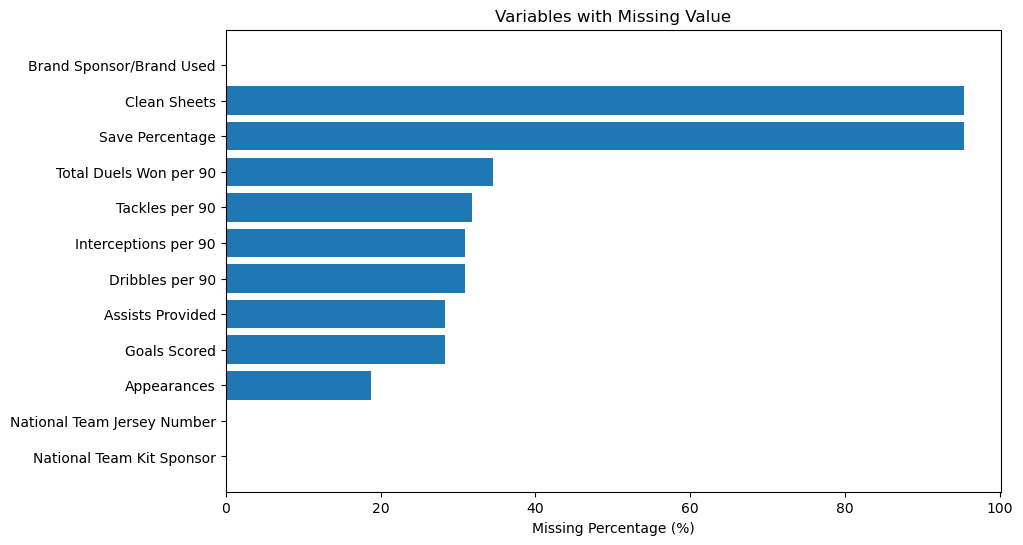

In [12]:
import matplotlib.pyplot as plt

# Create visualisation for missing values
plt.figure(figsize=(10,6))
plt.barh(missing_summary.index, missing_summary["Missing Percentage (%)"])
plt.xlabel("Missing Percentage (%)")
plt.title("Variables with Missing Value")
plt.show()

In [13]:
# Drop rows with any missing values
df_deleted = df.copy()
df_deleted = df_deleted.dropna(subset=numeric_cols)

print("Original shape:", df.shape)
print("After deletion:", df_deleted.shape)

Original shape: (814, 18)
After deletion: (1, 18)


In this project, delete the missing values are not suitable. Best used when missingness is MCAR, so deletion does not bias the dataset.

In [14]:
df_deleted.info()
print()
df_deleted.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 0 to 0
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nationality                  1 non-null      object        
 1   FIFA Ranking                 1 non-null      int64         
 2   National Team Kit Sponsor    1 non-null      object        
 3   Position                     1 non-null      object        
 4   National Team Jersey Number  1 non-null      float64       
 5   Player DOB                   1 non-null      datetime64[ns]
 6   Club                         1 non-null      object        
 7   Player Name                  1 non-null      object        
 8   Appearances                  1 non-null      float64       
 9   Goals Scored                 1 non-null      float64       
 10  Assists Provided             1 non-null      float64       
 11  Dribbles per 90              1 non-null      float64  

,Nationality,FIFA Ranking,National Team Kit Sponsor,Position,National Team Jersey Number,Player DOB,Club,Player Name,Appearances,Goals Scored,Assists Provided,Dribbles per 90,Interceptions per 90,Tackles per 90,Total Duels Won per 90,Save Percentage,Clean Sheets,Brand Sponsor/Brand Used
0,Argentina,2,Adidas,GK,23.0,1992-09-02,Aston Villa,Emiliano Martinez,7.0,0.0,0.0,0.0,0.0,0.0,0.65,46.67,43.0,Adidas


In [15]:
df.info()
print()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nationality                  814 non-null    object        
 1   FIFA Ranking                 814 non-null    int64         
 2   National Team Kit Sponsor    813 non-null    object        
 3   Position                     814 non-null    object        
 4   National Team Jersey Number  813 non-null    float64       
 5   Player DOB                   814 non-null    datetime64[ns]
 6   Club                         814 non-null    object        
 7   Player Name                  814 non-null    object        
 8   Appearances                  661 non-null    float64       
 9   Goals Scored                 584 non-null    float64       
 10  Assists Provided             584 non-null    float64       
 11  Dribbles per 90              563 non-null    

,Nationality,FIFA Ranking,National Team Kit Sponsor,Position,National Team Jersey Number,Player DOB,Club,Player Name,Appearances,Goals Scored,Assists Provided,Dribbles per 90,Interceptions per 90,Tackles per 90,Total Duels Won per 90,Save Percentage,Clean Sheets,Brand Sponsor/Brand Used
0,Argentina,2,Adidas,GK,23.0,1992-09-02,Aston Villa,Emiliano Martinez,7.0,0.0,0.0,0.00,0.00,0.0,0.65,46.67,43.0,Adidas
1,Argentina,2,Adidas,GK,1.0,1986-10-16,River,Franco Armani,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nike
2,Argentina,2,Adidas,GK,12.0,1992-05-20,Villarreal,Geronimo Rulli,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adidas
3,Argentina,2,Adidas,DF,19.0,1988-02-12,Benfica,Nicolas Otamendi,7.0,0.0,1.0,0.33,1.17,1.3,7.17,NaN,NaN,Nike
4,Argentina,2,Adidas,DF,8.0,1991-10-28,Sevilla,Marcos Acuna,6.0,0.0,0.0,1.45,0.48,2.9,7.97,NaN,NaN,Nike


In [16]:
df_imputed = df.copy()
print(df[numeric_cols].isnull().sum())
print()
for col in numeric_cols:
    median_val = df_imputed[col].median()
    df_imputed[col].fillna(median_val, inplace=True)
print(df_imputed[numeric_cols].isnull().sum())
#df_imputed.info()
df_imputed.head()

Appearances               153
Goals Scored              230
Assists Provided          230
Dribbles per 90           251
Interceptions per 90      251
Tackles per 90            259
Total Duels Won per 90    281
Save Percentage           776
Clean Sheets              776
dtype: int64

Appearances               0
Goals Scored              0
Assists Provided          0
Dribbles per 90           0
Interceptions per 90      0
Tackles per 90            0
Total Duels Won per 90    0
Save Percentage           0
Clean Sheets              0
dtype: int64


C:\Users\SAM\AppData\Local\Temp\ipykernel_24292\2382533386.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(median_val, inplace=True)


,Nationality,FIFA Ranking,National Team Kit Sponsor,Position,National Team Jersey Number,Player DOB,Club,Player Name,Appearances,Goals Scored,Assists Provided,Dribbles per 90,Interceptions per 90,Tackles per 90,Total Duels Won per 90,Save Percentage,Clean Sheets,Brand Sponsor/Brand Used
0,Argentina,2,Adidas,GK,23.0,1992-09-02,Aston Villa,Emiliano Martinez,7.0,0.0,0.0,0.00,0.00,0.0,0.65,46.670,43.0,Adidas
1,Argentina,2,Adidas,GK,1.0,1986-10-16,River,Franco Armani,0.0,0.0,0.0,0.66,0.50,1.3,5.12,64.695,22.5,Nike
2,Argentina,2,Adidas,GK,12.0,1992-05-20,Villarreal,Geronimo Rulli,0.0,0.0,0.0,0.66,0.50,1.3,5.12,64.695,22.5,Adidas
3,Argentina,2,Adidas,DF,19.0,1988-02-12,Benfica,Nicolas Otamendi,7.0,0.0,1.0,0.33,1.17,1.3,7.17,64.695,22.5,Nike
4,Argentina,2,Adidas,DF,8.0,1991-10-28,Sevilla,Marcos Acuna,6.0,0.0,0.0,1.45,0.48,2.9,7.97,64.695,22.5,Nike


Median is robust to skew and outliers and avoids bias from dropping rows. Median Imputation is suitable while handling MAR and the distribution is skewed.

In [19]:
# Impute missing values with 0
df_zero = df.copy()
df_zero[numeric_cols] = df_zero[numeric_cols].fillna(0)
print("Before 0-imputation", df[numeric_cols].isnull().sum())
print()
print("After 0-imputation", df_zero[numeric_cols].isnull().sum())

Before 0-imputation Appearances               153
Goals Scored              230
Assists Provided          230
Dribbles per 90           251
Interceptions per 90      251
Tackles per 90            259
Total Duels Won per 90    281
Save Percentage           776
Clean Sheets              776
dtype: int64

After 0-imputation Appearances               0
Goals Scored              0
Assists Provided          0
Dribbles per 90           0
Interceptions per 90      0
Tackles per 90            0
Total Duels Won per 90    0
Save Percentage           0
Clean Sheets              0
dtype: int64


Replacing missing numeric values with 0 is consistent with the semantics of player data. It encodes absence of participation or applicability, which is more meaningful than median/mean imputation in this context.

In [23]:
print(df.head())
print("After 0-imputation, clean sheet & save percentage are replaced with 0")
print(df_zero.head())

  Nationality  FIFA Ranking National Team Kit Sponsor Position  \
0   Argentina             2                    Adidas       GK   
1   Argentina             2                    Adidas       GK   
2   Argentina             2                    Adidas       GK   
3   Argentina             2                    Adidas       DF   
4   Argentina             2                    Adidas       DF   

   National Team Jersey Number Player DOB         Club        Player Name  \
0                         23.0 1992-09-02  Aston Villa  Emiliano Martinez   
1                          1.0 1986-10-16        River      Franco Armani   
2                         12.0 1992-05-20   Villarreal     Geronimo Rulli   
3                         19.0 1988-02-12      Benfica   Nicolas Otamendi   
4                          8.0 1991-10-28      Sevilla       Marcos Acuna   

   Appearances  Goals Scored  Assists Provided  Dribbles per 90  \
0          7.0           0.0               0.0             0.00   
1     

In [24]:
# Strategy 1: Delete rows
mean_deleted = df_deleted[numeric_cols].mean()
std_deleted = df_deleted[numeric_cols].std()

# Strategy 2: Median Imputation
mean_median = df_imputed[numeric_cols].mean()
std_median = df_imputed[numeric_cols].std()

# Strategy 3: Zero Imputation
mean_zero = df_zero[numeric_cols].mean()
std_zero = df_zero[numeric_cols].std()

# Compare results
comparison = pd.DataFrame({
    "Mean (Delete Rows)": mean_deleted,
    "Std (Delete Rows)": std_deleted,
    "Mean (Median Imputation)": mean_median,
    "Std (Median Imputation)": std_median,
    "Mean (Zero Imputation)": mean_zero,
    "Std (Zero Imputation)": std_zero
})

print(comparison)

                        Mean (Delete Rows)  Std (Delete Rows)  \
Appearances                           7.00                NaN   
Goals Scored                          0.00                NaN   
Assists Provided                      0.00                NaN   
Dribbles per 90                       0.00                NaN   
Interceptions per 90                  0.00                NaN   
Tackles per 90                        0.00                NaN   
Total Duels Won per 90                0.65                NaN   
Save Percentage                      46.67                NaN   
Clean Sheets                         43.00                NaN   

                        Mean (Median Imputation)  Std (Median Imputation)  \
Appearances                             2.863636                 1.498611   
Goals Scored                            0.203931                 0.639176   
Assists Provided                        0.136364                 0.437852   
Dribbles per 90                         1

# **Task B – Descriptive Statistics and Distribution Shape**

## B1. Univariate Summaries
#### For every numerical variable, compute **mean, median, standard deviation, IQR, minimum, maximum**, and the **5th and 95th percentiles**. Also report one **skewness coefficient** and one **excess kurtosis** value.

In [28]:
#import pandas as pd
#import numpy as np
from scipy.stats import skew, kurtosis
# mean, median, SD, IQR, min, max, percentiles, skewness, and kurtosis for every numerical variable
#Load dataset
#df_B = pd.read_csv("FIFA WC 2022 Players Stats.csv")
print("Proceed with data after 0-imputation")
#Select only numerical columns
#df_zero.info()
#df_zero.head()
numCol = df_zero.select_dtypes(include=[np.number]).columns
print(numCol)

Proceed with data after 0-imputation
Index(['FIFA Ranking', 'National Team Jersey Number', 'Appearances',
       'Goals Scored', 'Assists Provided', 'Dribbles per 90',
       'Interceptions per 90', 'Tackles per 90', 'Total Duels Won per 90',
       'Save Percentage', 'Clean Sheets'],
      dtype='object')


In [36]:
#create a function to calculate the mean,meidan,SD etc for each numeric columns
def cal_numbers(df_zero, col):
    data = df_zero[col]
    return {
        "mean": data.mean(),
        "median": data.median(),
        "SD": data.std(),
        "IQR": data.quantile(0.75) - data.quantile(0.25),
        "min": data.min(),
        "max": data.max(),
        "5thpercentile": data.quantile(0.05),
        "95thpercentile": data.quantile(0.95),
        "skewness": skew(data),
        "excess_kurtosis": kurtosis(data)
    }
# Apply to all numerical columns
calculated_numbers = {col: cal_numbers(df_zero, col) for col in numCol}
#print(calculated_numbers) #hard to read in dict form
#covnert dict to dataframe 
statistics_numbers=pd.DataFrame(calculated_numbers)
statistics_numbers.head()

,FIFA Ranking,National Team Jersey Number,Appearances,Goals Scored,Assists Provided,Dribbles per 90,Interceptions per 90,Tackles per 90,Total Duels Won per 90,Save Percentage,Clean Sheets
mean,21.713759,13.507995,2.299754,0.203931,0.136364,0.846916,0.64140,1.061536,3.535319,2.886695,1.144963
median,18.000000,14.000000,2.000000,0.000000,0.000000,0.000000,0.00000,0.400000,3.080000,0.000000,0.000000
SD,16.159655,7.523788,1.862051,0.639176,0.437852,2.137098,2.59304,1.502355,3.674040,13.712612,7.597249
IQR,20.000000,13.000000,2.000000,0.000000,0.000000,1.077500,0.83000,1.760000,6.100000,0.000000,0.000000
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000


In [40]:
statistics_numbersT=statistics_numbers.T
statistics_numbersT

,mean,median,SD,IQR,min,max,5thpercentile,95thpercentile,skewness,excess_kurtosis
FIFA Ranking,21.713759,18.00,16.159655,20.0000,1.0,60.00,2.0,58.0000,0.887244,-0.025023
National Team Jersey Number,13.507995,14.00,7.523788,13.0000,1.0,26.00,2.0,25.0000,NaN,NaN
Appearances,2.299754,2.00,1.862051,2.0000,0.0,7.00,0.0,6.0000,0.506169,-0.326869
Goals Scored,0.203931,0.00,0.639176,0.0000,0.0,8.00,0.0,1.0000,5.617620,47.862737
Assists Provided,0.136364,0.00,0.437852,0.0000,0.0,3.00,0.0,1.0000,3.741370,15.567645
Dribbles per 90,0.846916,0.00,2.137098,1.0775,0.0,36.00,0.0,3.7975,10.253144,151.876876
Interceptions per 90,0.641400,0.00,2.593040,0.8300,0.0,68.00,0.0,2.3300,21.911389,559.108665
Tackles per 90,1.061536,0.40,1.502355,1.7600,0.0,10.80,0.0,3.8435,2.196902,6.873979
Total Duels Won per 90,3.535319,3.08,3.674040,6.1000,0.0,18.49,0.0,10.0000,0.914830,0.632759
Save Percentage,2.886695,0.00,13.712612,0.0000,0.0,100.00,0.0,0.0000,4.729242,21.310325


#### Justification: for centre & speard
For each variable, recommend whether the mean or median should be the primary **measure of centre**, and whether standard deviation or IQR should be the primary **measure of spread**. Justify the recommendation using the actual **skewness**, **outliers**, and **practical meaning of the variable**

**Mean vs Median**: since mean is highly susceptible to outlier/extreme values, we can determine whether **outliers** exist by looking at the value of skewness, **the closer the skewness value to 0 means no extreme values in the data**,in this case only **Appearance** has low skewness value of 0.5 (others all have high skewness value than 1), thus we can use the **mean/average as the measure of center** for Appearance data; if the **skewness value is larger than 1 (>1 or <-1)**, means the **data is highly skewed**  and there maybe **outliers** in the data, for examples: **Interceptions per 90, Dribbles per 90, Goals Scored** etc, all these columns has **high skew value far larger than 1**, meaning there are extreme values such as 1 player can score 8 goals and some may score 0 scores, is this case **Median** is the better option for the measure of centre for all other data columns because extreme values can bias the mean values.

**Standard deviation vs IQR**: The measure of spread is used to describe how dispersed the data is around the centre of data. **Standatard deviation** is useful when the data distribution is a symmetrical shape and normally distributed (**low kurtosis**) like the columns **Appearance** and **FIFA Ranking** both have low kurtosis value of less than 1, meaning the data are more normally distributed, thus **Standard deviation** is applicable. For **IQR**, it captures the data from the 25th to 75th percentile, and thus can be used **for highly skewed data(high skewness) where outliers present** since it ignores the end tails outliers. For example, **all other columns** than the columns Appearance & FIFA Ranking, **have high kurtosis** value meaning they are **not normally distributed**, thus **IQR is a better measure of spread** as it focuses on the middle 50% range of data.


## B2. Outlier Investigation
#### 1.Apply the IQR fence rule to at least two numerical variables. 
#### 2.Apply the Z-score rule using |z| > 3 to the same variables. 
#### 3.Count how many values each method flags and whether the flagged sets overlap. 
#### 4.Investigate at least two flagged values in the raw data and decide whether they are plausible or likely errors.

In [69]:
##1. IQR fence rule to 2 numerical variable, flag extreme values, robust to skewness and heavy tails
goals = df_zero["Goals Scored"]
Q1goals=goals.quantile(0.25)
Q3goals=goals.quantile(0.75)
IQR_goals= Q3goals-Q1goals
upperfence_goals= Q3goals + 1.5*IQR_goals
lowerfence_goals= Q1goals - 1.5*IQR_goals
#print(Q1goals,Q3goals,IQR_goals,upperfence_goals,lowerfence_goals)
Flag_Goals= goals[(goals < lowerfence_goals) | (goals > upperfence_goals)]
#print("IQR fence rule Flagged values in Goals",Flag_Goals)
#print()
duelsper90= df_zero["Total Duels Won per 90"]
Q1duels=duelsper90.quantile(0.25)
Q3duels=duelsper90.quantile(0.75)
IQRduels= Q3duels-Q1duels
upperfence_duels= Q3duels + 1.5*IQRduels
lowerfence_duels= Q1duels - 1.5*IQRduels
#print(Q1duels,Q3duels,IQRduels,upperfence_duels,lowerfence_duels)
Flag_duels= duelsper90[(duelsper90 < lowerfence_duels) | (duelsper90 > upperfence_duels)]
#print("IQR fence rule Flagged values in Total Duels Won per 90",Flag_duels)
#print()
##2. Z-score rule |z|>3 to flag extreme values, Z score assume normal distribution
meangoals=goals.mean()
SDgoals=goals.std()
Zgoals= (goals - meangoals)/SDgoals
#print(meangoals,SDgoals)
#print(np.abs(Zgoals))
ZFlag_Goals= goals[np.abs(Zgoals) > 3]
#print("Z-score rule flagged values in Goals",ZFlag_Goals)
#print()
meanduels=duelsper90.mean()
SDduels=duelsper90.std()
Zduels= (duelsper90 - meanduels)/SDduels
#print(meanduels,SDduels)
#print(np.abs(Zduels))
ZFlag_duels= duelsper90[np.abs(Zduels) > 3]
#print("Z-score rule flagged values in Total Duels Won per 90",ZFlag_duels)
#print()
##3. Count how many values each method flags and whether the flagged sets overlap
print("Number of data in Goals", len(goals))
print("Number of data in Total Duels Won per 90 is", len(duelsper90))
print()
print("IQR fence rule Flagged values in Goals",len(Flag_Goals))
print("Z-score rule flagged values in Goals",len(ZFlag_Goals))
print("Overlap:", set(Flag_Goals) & set(ZFlag_Goals))
print()
print("IQR fence rule Flagged values in Total Duels Won per 90 is",len(Flag_duels))
print("Z-score rule flagged values in Total Duels Won per 90 is",len(ZFlag_duels))
print("Overlap:", set(Flag_duels) & set(ZFlag_duels))

Number of data in Goals 814
Number of data in Total Duels Won per 90 is 814

IQR fence rule Flagged values in Goals 115
Z-score rule flagged values in Goals 11
Overlap: {8.0, 3.0, 4.0, 7.0}

IQR fence rule Flagged values in Total Duels Won per 90 is 6
Z-score rule flagged values in Total Duels Won per 90 is 6
Overlap: {16.5, 17.48, 18.49, 18.0, 17.56, 17.3}


In [103]:
##4.Investigate at least two flagged values in the raw data and decide whether they are plausible or likely errors.
overlap_goals=set(Flag_Goals) & set(ZFlag_Goals)
print("Overlap Goals outliers:", overlap_goals)
#print(df_zero)
##4.Investigate at least two flagged values in the raw data 
print("Flagged Goals values in the raw data\n")
overlap_rows = df_zero[df_zero["Goals Scored"].isin(overlap_goals)]
##    [["Goals Scored","Postition"]]
print(overlap_rows)
#goals_overlap_rows = goals[goals.isin(overlap_goals)]
#print("The flagged goals numbers \n",goals_overlap_rows )
print("The flagged outliers are plausible, the players who score more than 3 are considered outliers when compared to players who didnt score at all.\n
The outlier players also have relatively high rankings in FIFA Ranking and their positions are all Forward, thus making sense that they have higher chance of scoring more goals")

Overlap Goals outliers: {8.0, 3.0, 4.0, 7.0}
Flagged Goals values in the raw data

      Nationality  FIFA Ranking National Team Kit Sponsor Position  \
19      Argentina             2                    Adidas       FW   
23      Argentina             2                    Adidas       FW   
45         France             3                      Nike       FW   
46         France             3                      Nike       FW   
127  Netherlands              6                      Nike       FW   
150       England             5                      Nike       FW   
151       England             5                      Nike       FW   
173        Brazil             1                      Nike       FW   
202      Portugal             9                      Nike       FW   
375         Spain            10                    Adidas       FW   
432      Ecuador             41                  Marathon       FW   

     National Team Jersey Number Player DOB               Club  \
19        

In [109]:
#overlap_duels= set(Flag_duels) & set(ZFlag_duels)
#print("Overlap Duels outliers:", overlap_duels)
#overlap_duels_rows =df_zero[df_zero["Total Duels Won per 90"].isin(overlap_duels)]
#print(overlap_duels_rows)

#### B3. Grouped Comparison [5 marks]
#### Choose one numerical variable and one categorical variable.
#### Produce a grouped summary table with per-group median, IQR, mean, and standard deviation.
#### Create a side-by-side box plot.
#### Write a brief comparison using centre, spread, shape, and outliers.


          Median  IQR      Mean       Std
Position                                 
DF           0.0  0.0  0.068702  0.253431
FW           0.0  1.0  0.550000  1.097049
GK           0.0  0.0  0.000000  0.000000
MF           0.0  0.0  0.149606  0.408966


<Figure size 1000x600 with 0 Axes>

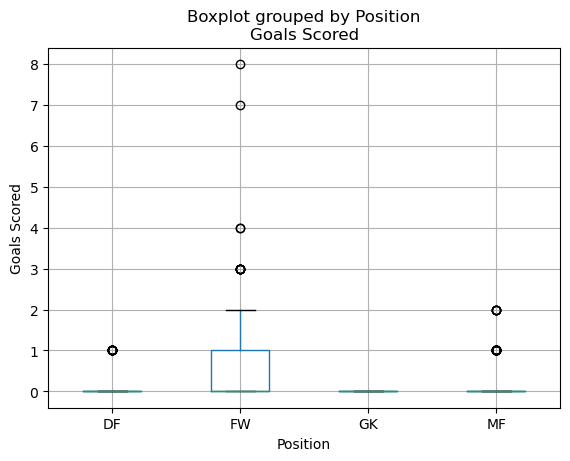

In [120]:
#numerical ->goals 
#categorical ->position
summary = df_zero.groupby("Position")["Goals Scored"].agg(
    Median="median",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Mean="mean",
    Std="std"
)
summary["IQR"] = summary["Q3"] - summary["Q1"]
print(summary[["Median", "IQR", "Mean", "Std"]])

plt.figure(figsize=(10,6))
df.boxplot(column="Goals Scored", by="Position", grid=True)
plt.ylabel("Goals Scored")
plt.show()

#### B4. Correlation and Covariance [4 marks]
#### Compute the Pearson correlation matrix for all numerical variables.
#### Identify the pair with the strongest linear association and the pair with the weakest.
#### Visualise the matrix as a heatmap.
#### For the strongest pair, produce a scatter plot and discuss whether Pearson’s coefficient fairly represents the relationship.

In [123]:
#Select only numerical columns
num_df = df_zero.select_dtypes(include=[np.number])
print(num_df)
num_df.info()

     FIFA Ranking  National Team Jersey Number  Appearances  Goals Scored  \
0               2                         23.0          7.0           0.0   
1               2                          1.0          0.0           0.0   
2               2                         12.0          0.0           0.0   
3               2                         19.0          7.0           0.0   
4               2                          8.0          6.0           0.0   
..            ...                          ...          ...           ...   
809            53                         17.0          3.0           0.0   
810            53                         19.0          3.0           1.0   
811            53                         20.0          3.0           0.0   
812            53                         23.0          1.0           0.0   
813            53                         12.0          0.0           0.0   

     Assists Provided  Dribbles per 90  Interceptions per 90  Tackles per 9

In [126]:
#Compute Pearson correlation matrix
PearCor = num_df.corr(method="pearson")
print(PearCor)

                             FIFA Ranking  National Team Jersey Number  \
FIFA Ranking                     1.000000                    -0.005580   
National Team Jersey Number     -0.005580                     1.000000   
Appearances                     -0.325883                    -0.161296   
Goals Scored                    -0.149986                    -0.025422   
Assists Provided                -0.174923                    -0.030782   
Dribbles per 90                 -0.010970                     0.042288   
Interceptions per 90            -0.044161                    -0.045591   
Tackles per 90                  -0.094476                    -0.026842   
Total Duels Won per 90          -0.170000                    -0.076492   
Save Percentage                 -0.033783                    -0.104734   
Clean Sheets                    -0.076146                    -0.105841   

                             Appearances  Goals Scored  Assists Provided  \
FIFA Ranking                   -0.3

In [135]:
#Flatten the matrix
corr_unstack = PearCor.unstack().dropna()
print(corr_unstack,"\n")
#Exclude self-correlations
corr_unstack_removedself = corr_unstack[corr_unstack.index.get_level_values(0) != corr_unstack.index.get_level_values(1)]
print(corr_unstack_removedself,"\n")
strongest_pair = corr_unstack_removedself.abs().idxmax()
print("Strongest linear association:",strongest_pair,"=",corr_unstack_removedself[strongest_pair],"\n")

weakest_pair = corr_unstack_removedself.abs().idxmin()
print("Weakest linear association:",weakest_pair,"=",corr_unstack_removedself[weakest_pair],"\n")

FIFA Ranking  FIFA Ranking                   1.000000
              National Team Jersey Number   -0.005580
              Appearances                   -0.325883
              Goals Scored                  -0.149986
              Assists Provided              -0.174923
                                               ...   
Clean Sheets  Interceptions per 90          -0.037324
              Tackles per 90                -0.106618
              Total Duels Won per 90        -0.141409
              Save Percentage                0.731722
              Clean Sheets                   1.000000
Length: 121, dtype: float64 

FIFA Ranking  National Team Jersey Number   -0.005580
              Appearances                   -0.325883
              Goals Scored                  -0.149986
              Assists Provided              -0.174923
              Dribbles per 90               -0.010970
                                               ...   
Clean Sheets  Dribbles per 90               -0.05979

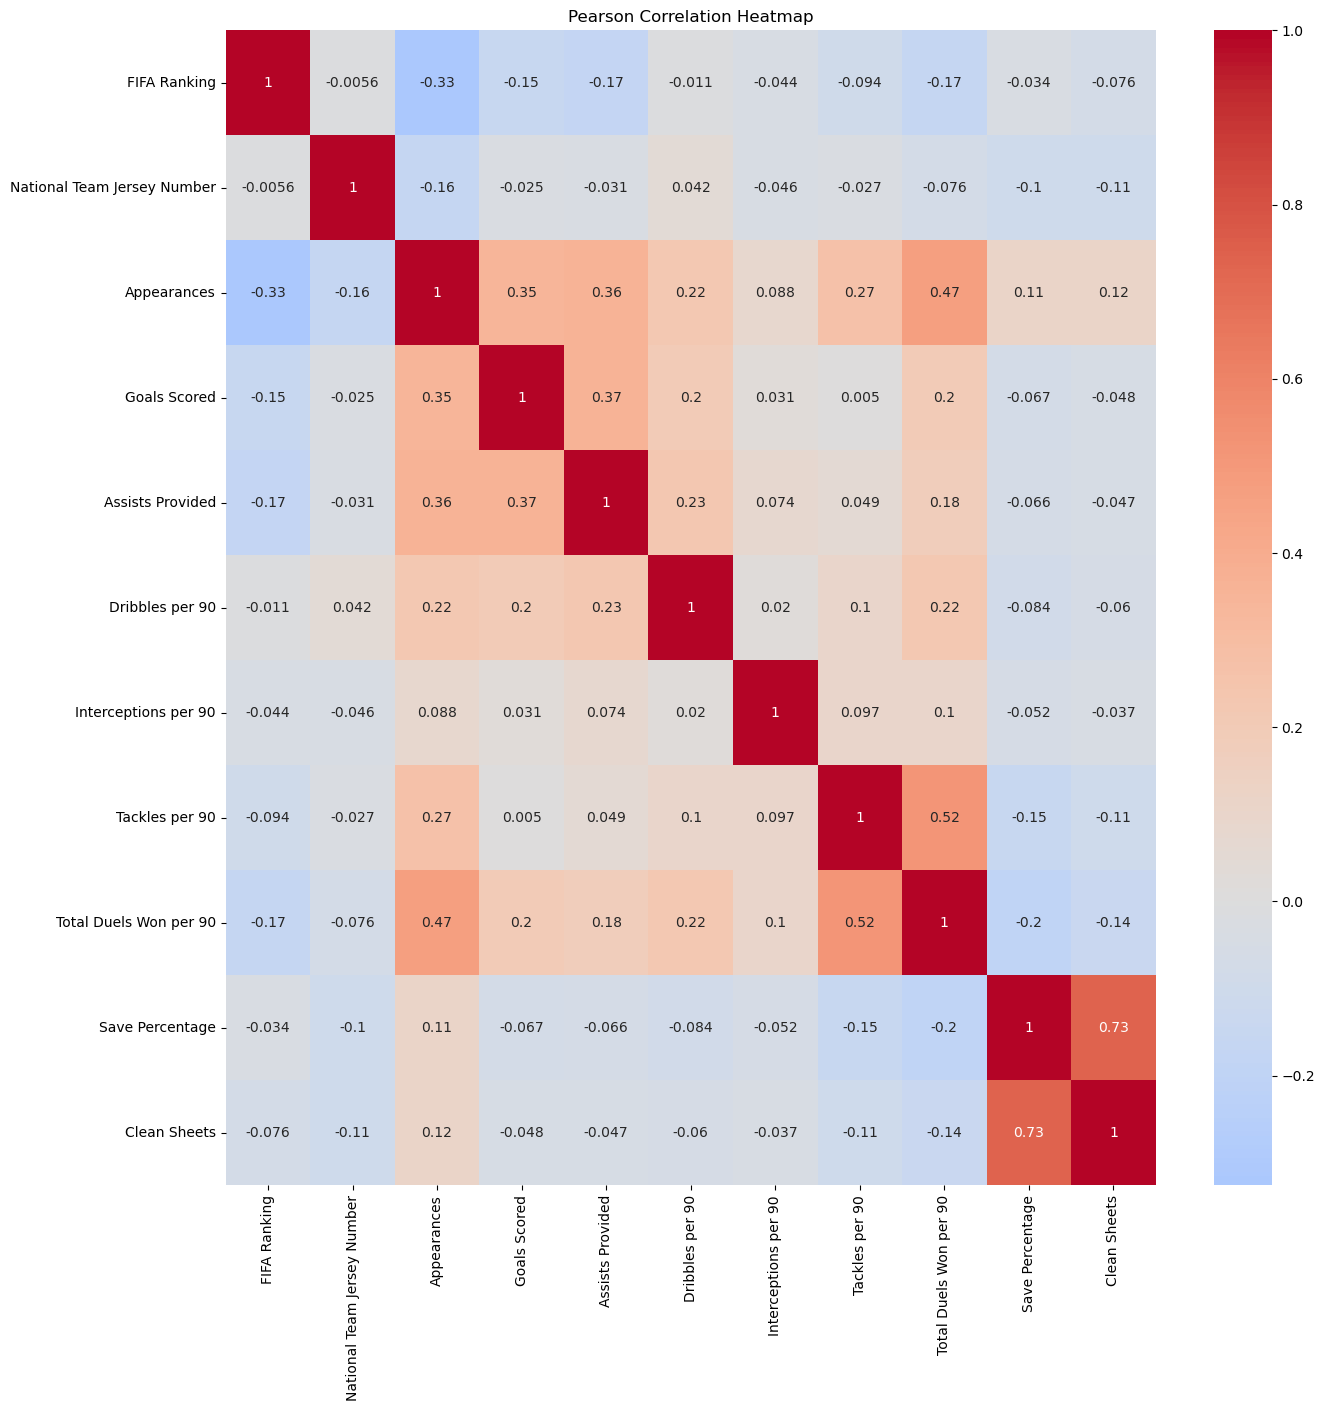

In [137]:
#Visualise correlation matrix as heatmap
import seaborn as seab
plt.figure(figsize=(15,15))
seab.heatmap(PearCor, annot=True, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Heatmap")
plt.show()

('Save Percentage', 'Clean Sheets')


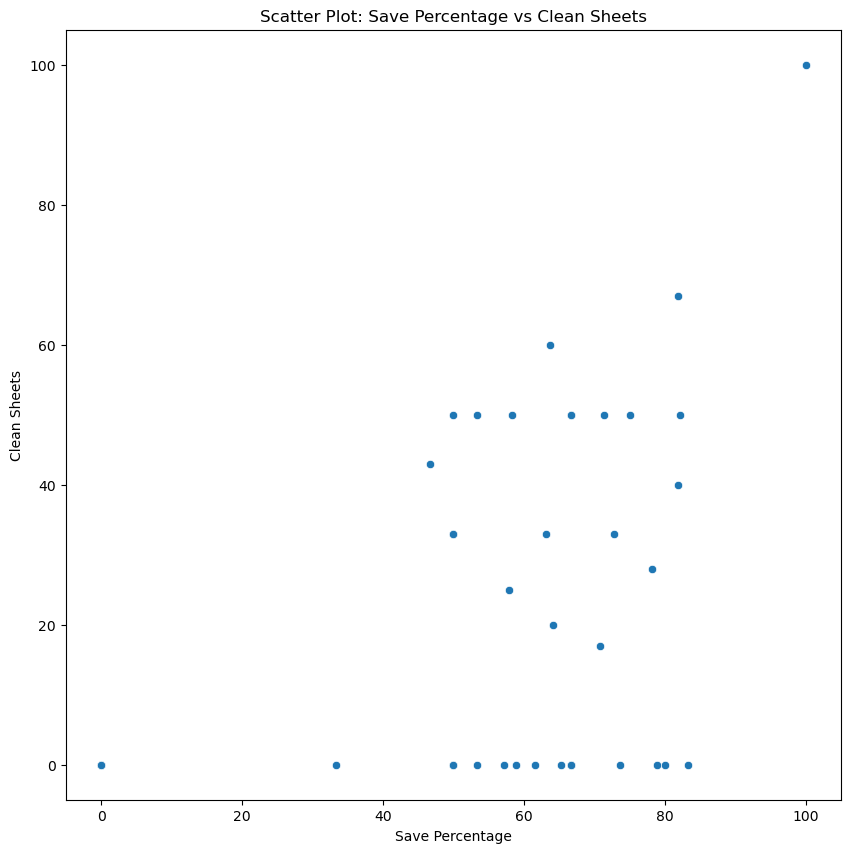

In [139]:
# Scatter plot for strongest pair
print(strongest_pair)
x,y=strongest_pair
plt.figure(figsize=(10,10))
seab.scatterplot(x=num_df[x], y=num_df[y])
plt.title(f"Scatter Plot: {x} vs {y}")
plt.xlabel(x)
plt.ylabel(y)
plt.show()


# **Task E: Statistical Distributions and Model Fitting**

## **Task E1:** Normality Assessment

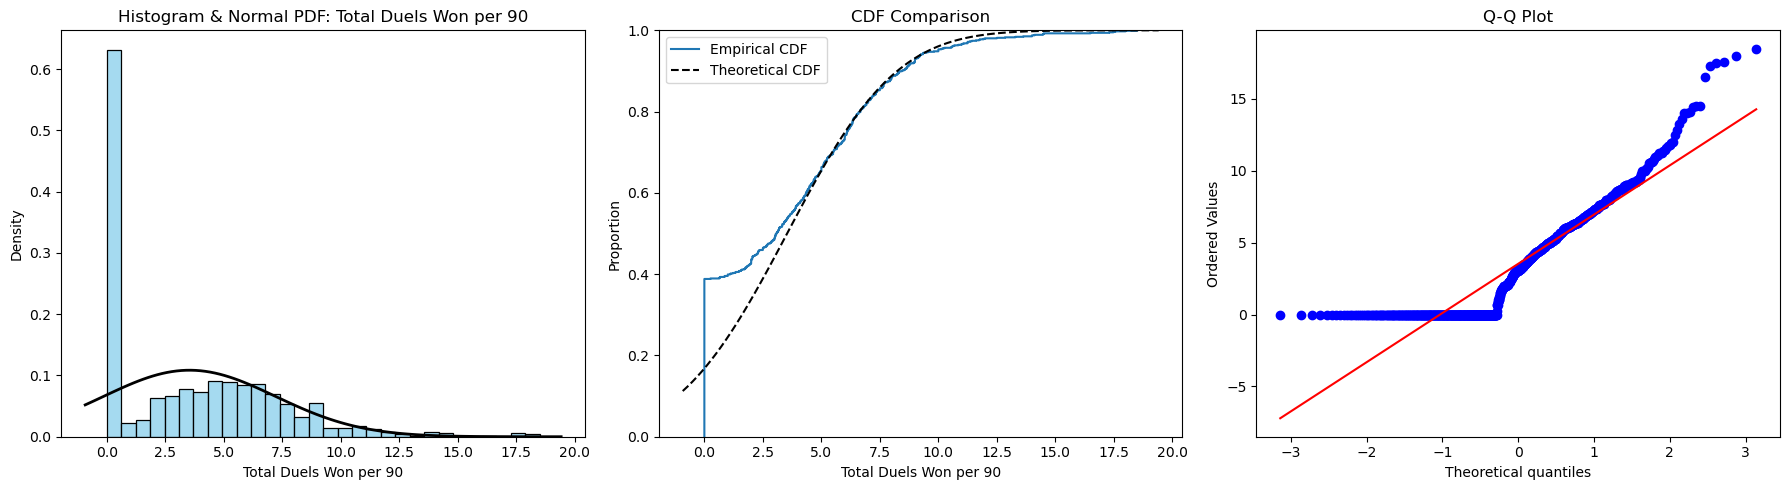

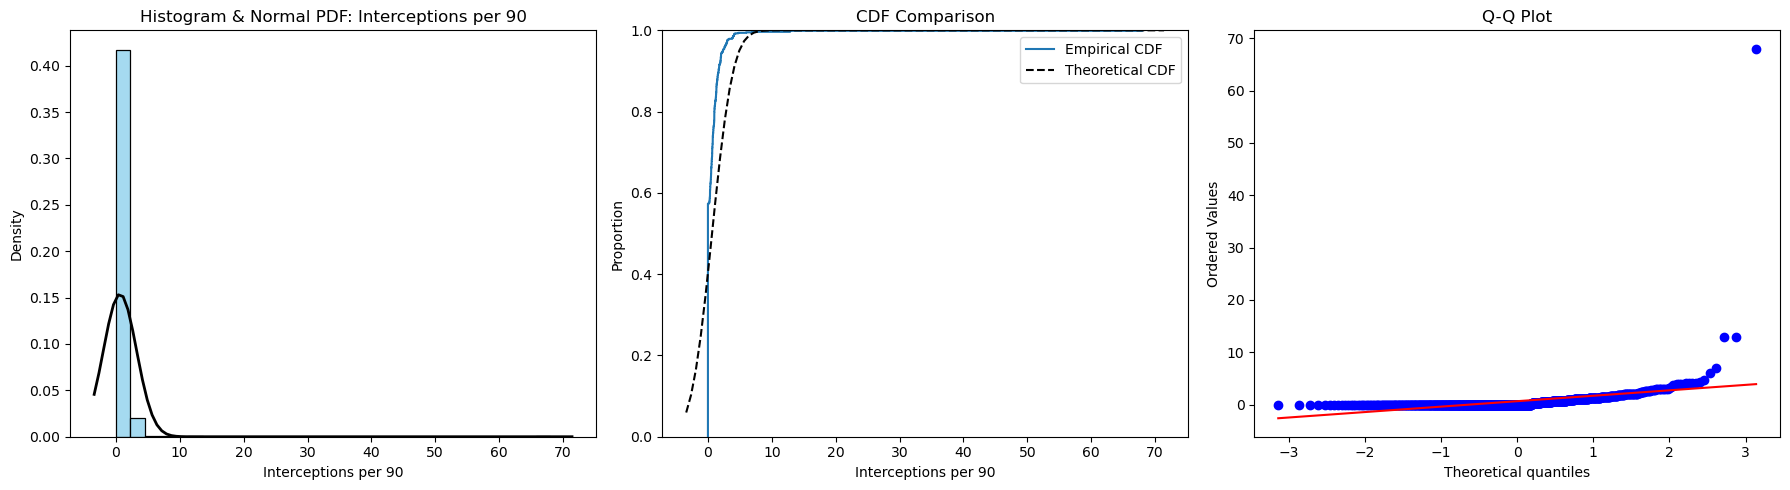

--- Shapiro-Wilk Test Results ---
Total Duels Won per 90: Statistic=0.8636, p-value=5.43857e-26
Interceptions per 90: Statistic=0.1658, p-value=1.14245e-50


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Load data using a relative path to comply with assignment rules
df_raw = pd.read_csv("FIFA WC 2022 Players Stats.csv")
df_raw.columns = df_raw.columns.str.strip()

# Create a specific dataframe for Task E to avoid overwriting previous variables
df_task_e = df_raw.copy()

# Clean and apply the zero imputation strategy
numeric_cols = [
    'Appearances', 'Goals Scored', 'Assists Provided', 
    'Dribbles per 90', 'Interceptions per 90', 'Tackles per 90', 
    'Total Duels Won per 90', 'Save Percentage', 'Clean Sheets'
]

df_task_e['Save Percentage'] = df_task_e['Save Percentage'].astype(str).str.replace('%', '', regex=False)
df_task_e['Clean Sheets'] = df_task_e['Clean Sheets'].astype(str).str.replace('%', '', regex=False)
df_task_e[numeric_cols] = df_task_e[numeric_cols].replace(['-', 'N,A', 'N.A', 'N.A.', ''], np.nan).astype(float)
df_task_e[numeric_cols] = df_task_e[numeric_cols].fillna(0)

# Select variables for normality testing
var_norm = df_task_e['Total Duels Won per 90']
var_skew = df_task_e['Interceptions per 90']

def plot_normality(data, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogram with Normal PDF
    sns.histplot(data, stat='density', bins=30, ax=axes[0], color='skyblue')
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(data), np.std(data, ddof=1))
    axes[0].plot(x, p, 'k', linewidth=2)
    axes[0].set_title(f'Histogram & Normal PDF: {title}')
    
    # ECDF vs Theoretical CDF
    sns.ecdfplot(data, ax=axes[1], label='Empirical CDF')
    axes[1].plot(x, stats.norm.cdf(x, np.mean(data), np.std(data, ddof=1)), 'k--', label='Theoretical CDF')
    axes[1].set_title('CDF Comparison')
    axes[1].legend()
    
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()

# Generate plots
plot_normality(var_norm, 'Total Duels Won per 90')
plot_normality(var_skew, 'Interceptions per 90')

# Shapiro-Wilk Tests
stat_norm, p_norm = stats.shapiro(var_norm)
stat_skew, p_skew = stats.shapiro(var_skew)

print("--- Shapiro-Wilk Test Results ---")
print(f"Total Duels Won per 90: Statistic={stat_norm:.4f}, p-value={p_norm:.5e}")
print(f"Interceptions per 90: Statistic={stat_skew:.4f}, p-value={p_skew:.5e}")

The Q-Q plot compares our dataset's empirical quantiles (y-axis) against the theoretical quantiles of a perfectly normal distribution (x-axis), which forms a straight diagonal line. Right-skew appears as points curving upwards above the diagonal line on the right side. Left-skew appears as points curving downwards below the line on the left side. Heavy tails appear as points deviating significantly from the line at both extreme ends. For `Total Duels Won per 90`, we observe a vertical grouping of points at the bottom. This is an artifact of our zero-imputation strategy. Otherwise, the middle quantiles follow the diagonal reasonably well, making it our best candidate for an approximately normal variable. Conversely, `Interceptions per 90` is heavily right-skewed.

For the Shapiro-Wilk test, the null hypothesis ($H_0$) is that the data is drawn from a normally distributed population, and the alternative hypothesis ($H_1$) is that it is not. Both variables yield a p-value < 0.05, leading us to reject the null hypothesis. With a sample size of over 800 players, the Shapiro-Wilk test has immense statistical power and will flag even the smallest deviations (like our zero-imputed values) as statistically significant non-normality.

## **Task E2:** Fitting a Discrete Distribution

Mean (Lambda): 0.2039
Variance: 0.4085
Dispersion Ratio (Variance/Mean): 2.0033


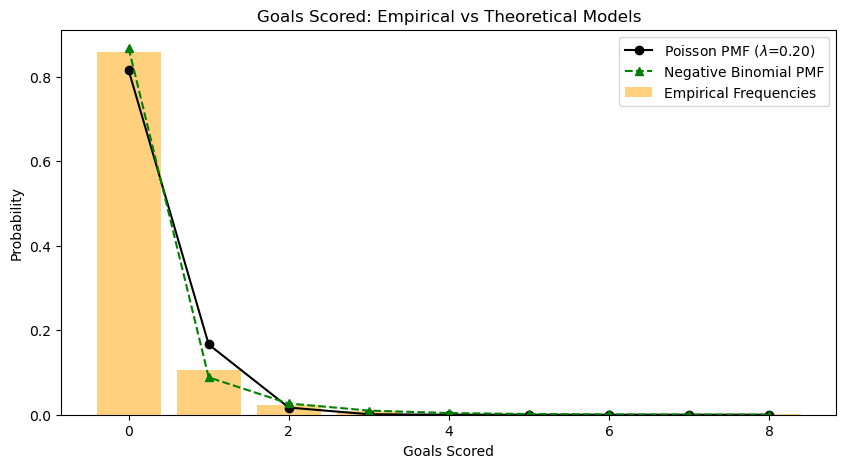

In [2]:
# Select count variable
goals = df_task_e['Goals Scored']

mean_goals = np.mean(goals)
var_goals = np.var(goals, ddof=1)
dispersion_ratio = var_goals / mean_goals

print(f"Mean (Lambda): {mean_goals:.4f}")
print(f"Variance: {var_goals:.4f}")
print(f"Dispersion Ratio (Variance/Mean): {dispersion_ratio:.4f}")

# Plotting frequencies
val_counts = goals.value_counts(normalize=True).sort_index()
x_vals = np.arange(0, goals.max() + 1)
poisson_pmf = stats.poisson.pmf(x_vals, mean_goals)

# Fit Negative Binomial (estimating parameters using method of moments)
r = (mean_goals**2) / (var_goals - mean_goals)
prob_nbinom = r / (r + mean_goals)
nbinom_pmf = stats.nbinom.pmf(x_vals, r, prob_nbinom)

plt.figure(figsize=(10,5))
plt.bar(val_counts.index, val_counts.values, alpha=0.5, label='Empirical Frequencies', color='orange')
plt.plot(x_vals, poisson_pmf, 'ko-', label=f'Poisson PMF ($\lambda$={mean_goals:.2f})')
plt.plot(x_vals, nbinom_pmf, 'g^--', label='Negative Binomial PMF')
plt.title('Goals Scored: Empirical vs Theoretical Models')
plt.xlabel('Goals Scored')
plt.ylabel('Probability')
plt.legend()
plt.show()

The Poisson distribution assumes that events (goals) occur independently at a constant average rate ($\lambda$). Mathematically, this model requires the mean and variance to be equal (Dispersion Ratio = 1). Our calculated dispersion ratio is much greater than 1, indicating heavy over-dispersion. The variance significantly exceeds the mean. In the context of football, this makes logical sense: goals are not independent, random events. A few elite strikers score a disproportionately high number of goals, while the vast majority of players score zero. Because the Poisson model fails to account for this excess variance, a Negative Binomial distribution is a much more appropriate generalisation, as it includes a second parameter specifically designed to handle over-dispersed count data.

## **Task E3:** Normal Probability Questions

In [3]:
mu = np.mean(var_norm)
sigma = np.std(var_norm, ddof=1)
dist = stats.norm(loc=mu, scale=sigma)

# Percentage above 90th percentile
p90 = np.percentile(var_norm, 90)
prob_above_p90 = dist.sf(p90) * 100 

# Probability between Q1 and Q3
q1, q3 = np.percentile(var_norm, [25, 75])
prob_iqr = dist.cdf(q3) - dist.cdf(q1)

# Bottom 5% separator
bottom_5_cutoff = dist.ppf(0.05)

print(f"Distribution Parameters: μ = {mu:.2f}, σ = {sigma:.2f}")
print(f"Probability above 90th empirical percentile ({p90:.2f}): {prob_above_p90:.2f}%")
print(f"Probability between Q1 ({q1:.2f}) and Q3 ({q3:.2f}): {prob_iqr:.4f}")
print(f"Value separating the bottom 5%: {bottom_5_cutoff:.2f}\n")

# Empirical Rule (68% and 95%)
within_1_std = dist.cdf(mu + sigma) - dist.cdf(mu - sigma)
within_2_std = dist.cdf(mu + 2*sigma) - dist.cdf(mu - 2*sigma)
print(f"Probability within 1 standard deviation: {within_1_std:.4f} (Empirical rule: ~0.68)")
print(f"Probability within 2 standard deviations: {within_2_std:.4f} (Empirical rule: ~0.95)\n")

# Z-score of highest value
max_val = var_norm.max()
z_score_max = (max_val - mu) / sigma
print(f"Highest value ({max_val}) Z-score: {z_score_max:.2f}")

Distribution Parameters: μ = 3.54, σ = 3.67
Probability above 90th empirical percentile (8.41): 9.24%
Probability between Q1 (0.00) and Q3 (6.10): 0.5895
Value separating the bottom 5%: -2.51

Probability within 1 standard deviation: 0.6827 (Empirical rule: ~0.68)
Probability within 2 standard deviations: 0.9545 (Empirical rule: ~0.95)

Highest value (18.49) Z-score: 4.07


The mathematical formula for the Normal Probability Density Function (PDF) inherently relies entirely on just two variables: the mean ($\mu$) and the standard deviation ($\sigma$). The rest of the equation consists of mathematical constants. Therefore, $\mu$ dictates the exact center of the distribution, and $\sigma$ dictates the exact spread or width of the bell curve. Because no other parameters exist in the formula, knowing these two values fully defines the distribution's shape and allows us to calculate any area under the curve.

Additionally, the z-score of the highest value tells us exactly how many standard deviations the maximum observation is above the mean. A z-score of this magnitude indicates an extreme outlier under the normal model, meaning the probability of observing this value in a perfectly normal distribution is practically zero.

## **Task E4:** Lognormal or Alternative Transformation

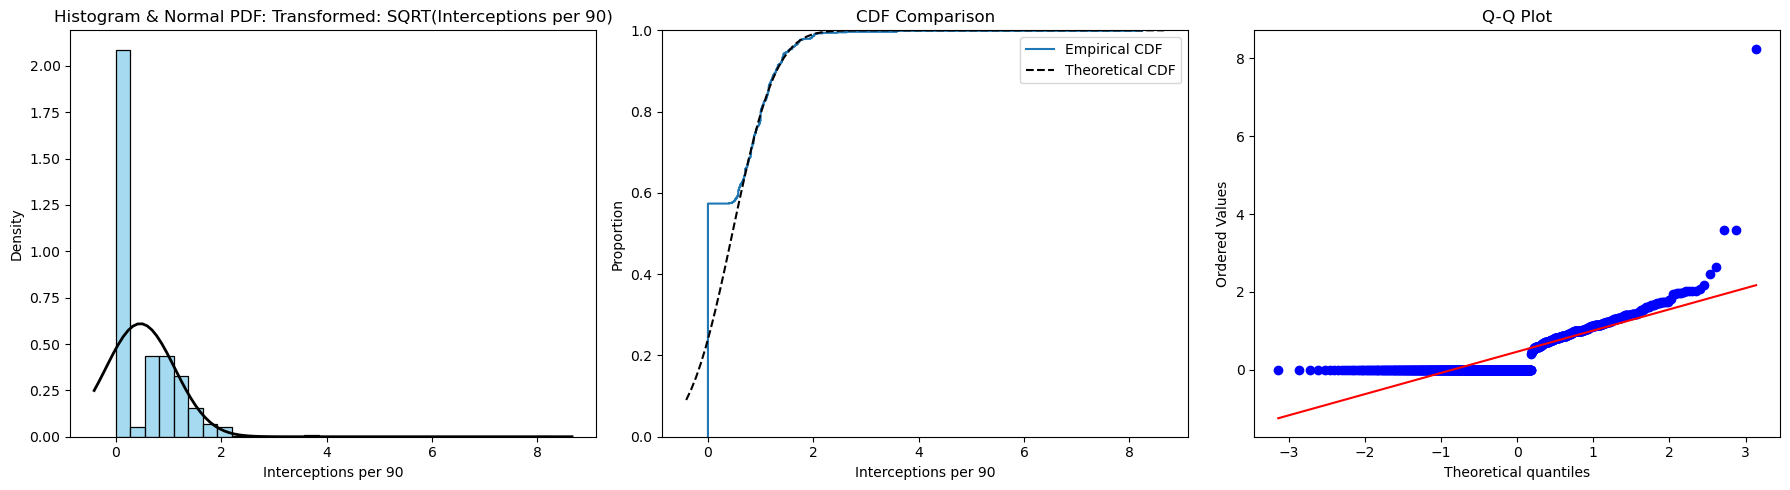

Transformed Shapiro-Wilk: Statistic=0.6940, p-value=5.99803e-36


In [4]:
# Apply a square-root transformation for variables containing zeros
var_skew_transformed = np.sqrt(var_skew)

plot_normality(var_skew_transformed, 'Transformed: SQRT(Interceptions per 90)')

stat_trans, p_trans = stats.shapiro(var_skew_transformed)
print(f"Transformed Shapiro-Wilk: Statistic={stat_trans:.4f}, p-value={p_trans:.5e}")

Mathematically, a variable $X$ is lognormally distributed if its logarithm, $Y = \ln(X)$, is normally distributed. However, because our empirical dataset contains exact zero values, a standard logarithmic transformation is mathematically undefined. Therefore, to comply with the methodology requirements for zero-inflated variables, we applied a square-root transformation instead.

Lognormal distributions typically describe real-world data generated by multiplicative, compounding processes rather than additive ones. Applying a transformation compresses the extreme long right tail of the interceptions data, pulling the heavy outliers closer to the mean and making the distribution more symmetrical (bell-shaped), which allows it to play nicer with parametric statistical tests.